In [ ]:
# ============================================================
# 1일차 오전: BPE → Self-Attention 시각화 → Positional Encoding
# 프레임워크: Keras (TF 2.x)  |  토크나이저: HuggingFace tokenizers
# 목표: 오후 Decoder-only 추론의 개념 기반 구축
# ============================================================

!pip install -q tokenizers transformers tensorflow matplotlib seaborn koreanize-matplotlib


# ────────────────────────────────────────────────────────────
# 블록 1: BPE Subword 토크나이저 (40분)
# ────────────────────────────────────────────────────────────
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing
import koreanize_matplotlib
import json

## 1-1. 학습 말뭉치 준비 (연구 도메인 샘플)
corpus = [
    "자연어처리는 인공지능의 핵심 분야이다",
    "트랜스포머 모델은 어텐션 메커니즘을 사용한다",
    "연구데이터를 효율적으로 관리하는 방법이 필요하다",
    "딥러닝 기반 언어모델은 대규모 텍스트로 사전학습된다",
    "서브워드 토크나이징은 미등록어 문제를 완화한다",
    "바이트페어인코딩은 자주 등장하는 문자쌍을 병합한다",
    "어텐션 가중치는 토큰 간 관련성을 나타낸다",
    "포지셔널 인코딩은 순서 정보를 벡터에 추가한다",
    "디코더는 이전 토큰을 참고하여 다음 토큰을 예측한다",
    "온도 파라미터는 생성 텍스트의 다양성을 조절한다",
] * 20  # 반복으로 어휘 학습 안정화

with open("corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(corpus))

## 1-2. BPE 토크나이저 학습
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=500,
    min_frequency=2,
    special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"],
    show_progress=True
)
tokenizer.train(files=["corpus.txt"], trainer=trainer)

## 1-3. 토크나이징 시각화 — BPE의 핵심: 서브워드 분절
test_words = [
    "트랜스포머",          # 학습 어휘
    "트랜스포머모델",      # 합성어
    "어텐션메커니즘",      # 합성어
    "미등록어테스트단어",  # 미등록어 → 서브워드로 분절
]

print("=" * 55)
print("BPE 서브워드 토크나이징 결과")
print("=" * 55)
for word in test_words:
    enc = tokenizer.encode(word)
    print(f"\n입력: {word}")
    print(f"  토큰:  {enc.tokens}")
    print(f"  ID:    {enc.ids}")
    print(f"  분절 수: {len(enc.tokens)}개")

## 1-4. 어휘 병합 규칙 시각화 (BPE 원리 설명)
print("\n" + "=" * 55)
print("BPE 병합 원리 시뮬레이션")
print("=" * 55)

def bpe_demo(text):
    """BPE 병합 과정을 단계별로 보여주는 시뮬레이션"""
    chars = list(text)
    print(f"\n원본: '{text}'")
    print(f"초기 문자 분리: {chars}")

    # 실제 BPE 결과와 비교
    enc = tokenizer.encode(text)
    print(f"BPE 적용 후:    {enc.tokens}")
    print(f"→ 자주 등장하는 문자쌍이 하나의 토큰으로 병합됨")

bpe_demo("트랜스포머")
bpe_demo("어텐션")
bpe_demo("포지셔널인코딩")

## 1-5. Word-level vs BPE 비교
print("\n" + "=" * 55)
print("Word-level vs BPE 어휘 처리 비교")
print("=" * 55)
unseen = "멀티헤드어텐션레이어"
enc = tokenizer.encode(unseen)
print(f"\n미등록 합성어: '{unseen}'")
print(f"Word-level → [UNK] (정보 손실 100%)")
print(f"BPE        → {enc.tokens}  (부분 의미 보존)")
print(f"\n★ 핵심: BPE는 미등록어를 알려진 서브워드로 분해 → GPT·BERT 모두 BPE 계열 사용")

BPE 서브워드 토크나이징 결과

입력: 트랜스포머
  토큰:  ['트랜스포머']
  ID:    [251]
  분절 수: 1개

입력: 트랜스포머모델
  토큰:  ['트랜스포머', '모', '델']
  ID:    [251, 41, 23]
  분절 수: 3개

입력: 어텐션메커니즘
  토큰:  ['어텐션', '메커', '니즘']
  ID:    [136, 164, 151]
  분절 수: 3개

입력: 미등록어테스트단어
  토큰:  ['미등록어', '[UNK]', '스트', '[UNK]', '어']
  ID:    [235, 0, 130, 0, 66]
  분절 수: 5개

BPE 병합 원리 시뮬레이션

원본: '트랜스포머'
초기 문자 분리: ['트', '랜', '스', '포', '머']
BPE 적용 후:    ['트랜스포머']
→ 자주 등장하는 문자쌍이 하나의 토큰으로 병합됨

원본: '어텐션'
초기 문자 분리: ['어', '텐', '션']
BPE 적용 후:    ['어텐션']
→ 자주 등장하는 문자쌍이 하나의 토큰으로 병합됨

원본: '포지셔널인코딩'
초기 문자 분리: ['포', '지', '셔', '널', '인', '코', '딩']
BPE 적용 후:    ['포지셔널', '인코', '딩']
→ 자주 등장하는 문자쌍이 하나의 토큰으로 병합됨

Word-level vs BPE 어휘 처리 비교

미등록 합성어: '멀티헤드어텐션레이어'
Word-level → [UNK] (정보 손실 100%)
BPE        → ['[UNK]', '[UNK]', '[UNK]', '드', '어텐션', '[UNK]', '이', '어']  (부분 의미 보존)

★ 핵심: BPE는 미등록어를 알려진 서브워드로 분해 → GPT·BERT 모두 BPE 계열 사용


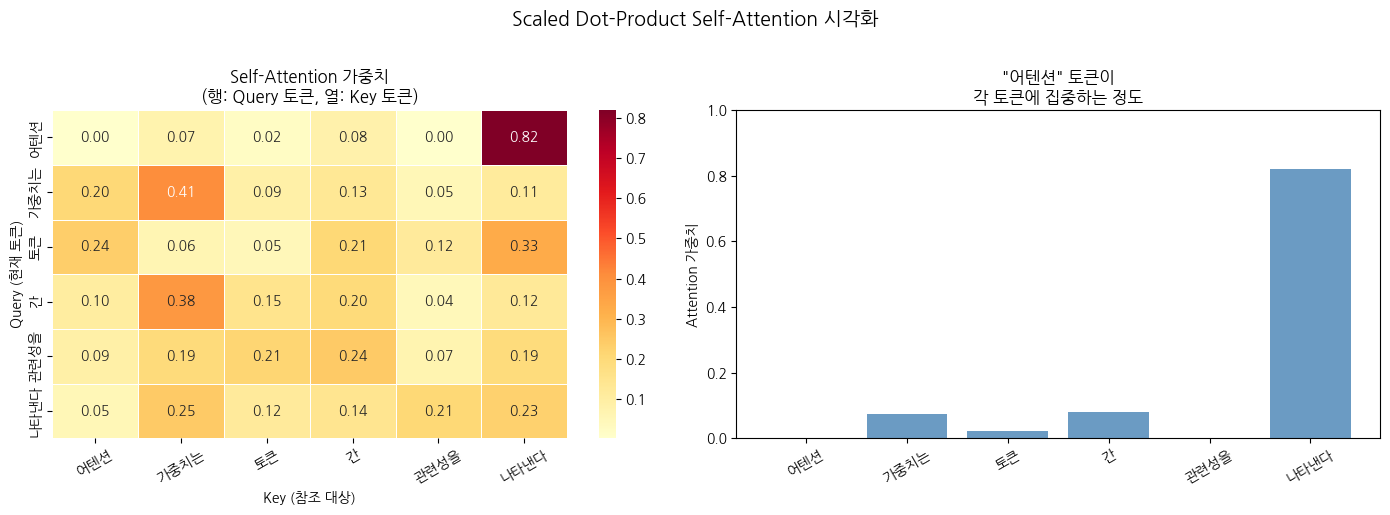

★ 읽는 법: 행(Query 토큰)이 열(Key 토큰)을 얼마나 참고하는지를 색 농도로 표현
★ RAG 연결: 질문 토큰이 문서 토큰 중 어느 부분에 집중하는지 — 같은 원리


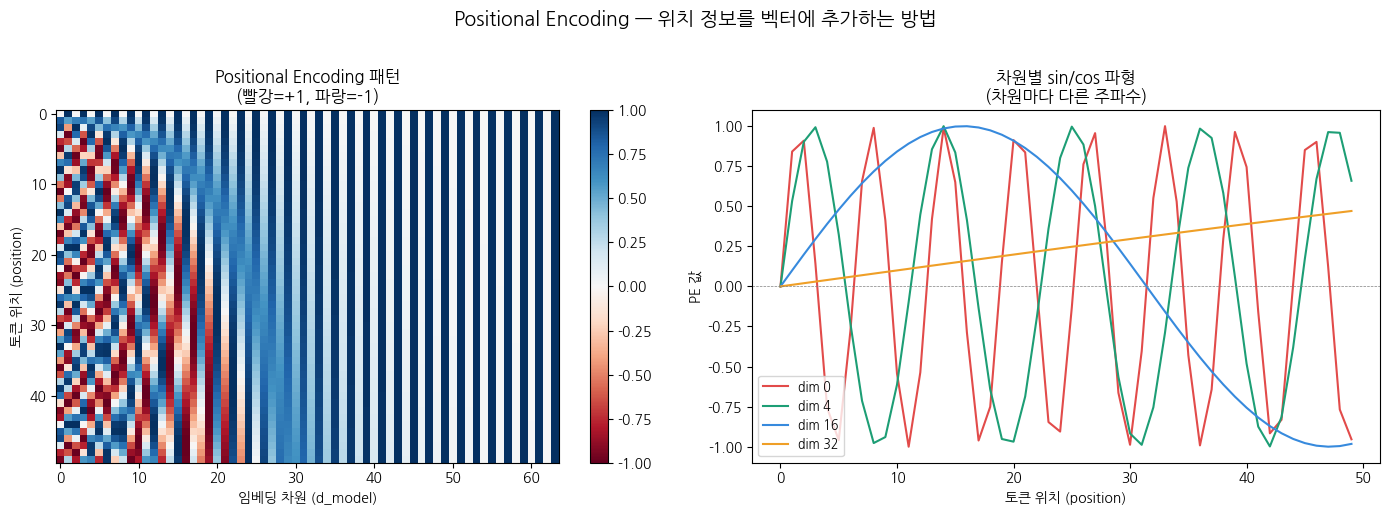


위치 간 PE 코사인 유사도:
(가까운 위치일수록 유사한 벡터 → 모델이 상대적 위치 학습 가능)
----------------------------------------
  위치  0 ↔ 위치  1: 0.966  ███████████████████
  위치  0 ↔ 위치  5: 0.734  ██████████████
  위치  0 ↔ 위치 25: 0.629  ████████████
  위치  0 ↔ 위치 49: 0.475  █████████

★ 핵심 요약
  Self-Attention 자체는 순서 정보가 없음 (집합 연산)
  → PE를 임베딩에 더해 위치 정보 주입
  → 토큰 벡터 = 의미(임베딩) + 위치(PE)
  → 오후 Decoder: 이 벡터로 '다음 위치의 토큰'을 예측


In [2]:
# ────────────────────────────────────────────────────────────
# 블록 3: Positional Encoding (30분)
# sin/cos 패턴 시각화 + 위치 정보 역할 이해
# ────────────────────────────────────────────────────────────

## 3-1. Positional Encoding 구현
def positional_encoding(max_len, d_model):
    """
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    positions = np.arange(max_len)[:, np.newaxis]      # (max_len, 1)
    dims      = np.arange(d_model)[np.newaxis, :]      # (1, d_model)

    angles = positions / np.power(10000, (2 * (dims // 2)) / d_model)
    pe = np.where(dims % 2 == 0, np.sin(angles), np.cos(angles))
    return pe   # (max_len, d_model)

## 3-2. 시각화 1: PE 패턴 히트맵
max_len, d_model_pe = 50, 64
pe = positional_encoding(max_len, d_model_pe)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(pe, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_xlabel("임베딩 차원 (d_model)")
axes[0].set_ylabel("토큰 위치 (position)")
axes[0].set_title("Positional Encoding 패턴\n(빨강=+1, 파랑=-1)", fontsize=12)
plt.colorbar(im, ax=axes[0])

## 3-3. 시각화 2: 특정 차원의 sin/cos 파형
dims_to_plot = [0, 4, 16, 32]
colors = ['#E24B4A', '#1D9E75', '#378ADD', '#EF9F27']
for d, c in zip(dims_to_plot, colors):
    axes[1].plot(pe[:, d], label=f"dim {d}", color=c, linewidth=1.5)

axes[1].set_xlabel("토큰 위치 (position)")
axes[1].set_ylabel("PE 값")
axes[1].set_title("차원별 sin/cos 파형\n(차원마다 다른 주파수)", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle("Positional Encoding — 위치 정보를 벡터에 추가하는 방법", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("positional_encoding.png", dpi=150, bbox_inches='tight')
plt.show()

## 3-4. 위치 유사도 — 가까운 위치끼리 유사한 PE 벡터
from numpy.linalg import norm

def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b) + 1e-8)

pos_pairs = [(0,1), (0,5), (0,25), (0,49)]
print("\n위치 간 PE 코사인 유사도:")
print("(가까운 위치일수록 유사한 벡터 → 모델이 상대적 위치 학습 가능)")
print("-" * 40)
for p1, p2 in pos_pairs:
    sim = cosine_sim(pe[p1], pe[p2])
    bar = "█" * int(sim * 20)
    print(f"  위치 {p1:2d} ↔ 위치 {p2:2d}: {sim:.3f}  {bar}")

## 3-5. 임베딩 + PE 결합 시각화
print("\n★ 핵심 요약")
print("  Self-Attention 자체는 순서 정보가 없음 (집합 연산)")
print("  → PE를 임베딩에 더해 위치 정보 주입")
print("  → 토큰 벡터 = 의미(임베딩) + 위치(PE)")
print("  → 오후 Decoder: 이 벡터로 '다음 위치의 토큰'을 예측")